# Chapter 01: Introduction

**Source orientation.** Printed pages 4; physical PDF pages 8. This notebook is an original, executable lesson built from the chapter's concepts and structure. It does not reproduce textbook prose, exercises, figures, screenshots, or page crops.

**Chapter question.** Representation learning, structured data, symmetry preview, and the GDL design loop.

## Route Through The Notebook

- Translate the chapter's core ideas into domain, transformation, representation, and check vocabulary.
- Generate visual artifacts under `artifacts/chapter-01/` and display them inline.
- Record numerical residuals or structural checks in a JSON ledger.
- End with a small lab prompt so the reader can test the geometric assumption.


In [1]:

from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / '00-book-index.ipynb').exists() and (candidate / 'utils').exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError('Could not find the Geometric Deep Learning course root')

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

import pandas as pd
from IPython.display import display
from utils.artifacts import assert_artifacts, display_artifact, save_json
from utils.course_visuals import build_chapter_visuals
from utils.notebook_checks import file_size, image_nonblank

CHAPTER = 1
print(f'Book root: {BOOK_ROOT}')


Book root: D:\Geometry\Geometric-Deep-Learning


## Translation Guide

Raw coordinates are not the same as a geometric domain. A grid, graph, point cloud, or surface tells us which transformations preserve meaning and which outputs should move with the input.

The chapter introduces the constructive loop used by the whole course: identify the domain, choose transformations, decide invariant or equivariant behavior, build local shared computations, then test the residual.

The visuals preview this loop with structured samples, image translations, graph relabelings, molecule-like point clouds, and a taxonomy linking domains to model families.

The code cells below use shared helpers from `utils/` rather than hidden external assets. Every visual is regenerated from synthetic data so the chapter remains portable and inspectable. The checks are intentionally small but they target the same invariants that larger systems rely on: permutation equivariance, rigid-motion invariance, translation equivariance, spectral consistency, or graph-structured information flow.

## Working Vocabulary

- `domain`: the object that indexes the signal, such as a grid, graph, group, point cloud, surface, or sequence.
- `signal`: the values living on the domain.
- `transformation`: a change of coordinates or domain elements whose effect should be predictable.
- `invariant`: a quantity that should not change after an allowed transformation.
- `equivariant`: an output that should transform in the same organized way as the input.
- `artifact`: a generated figure, HTML view, table, or JSON file saved under the course-local artifact tree.


In [2]:

ARTIFACTS, CHECKS = build_chapter_visuals(CHAPTER)
print(f'Generated {len(ARTIFACTS)} artifacts for chapter {CHAPTER:02d}')
for path in ARTIFACTS:
    print(path.relative_to(BOOK_ROOT))


Generated 6 artifacts for chapter 01
artifacts\chapter-01\figures\representation-learning-stack.png
artifacts\chapter-01\figures\ambient-vs-structured-data.png
artifacts\chapter-01\figures\symmetry-action-gallery.png
artifacts\chapter-01\html\equivariance-mini-lab.html
artifacts\chapter-01\figures\geometric-blueprint-taxonomy.png
artifacts\chapter-01\checks\chapter-01-visual-ledger.json


## Source-Grounded Visual Storyboard And Library Routing

Chapter 1 is short, but it sets the contract for the whole course. The source page introduces modern high-dimensional learning successes, then narrows the explanation to two algorithmic ingredients: learned representations and local gradient-descent training. The important geometric turn is that real tasks are not arbitrary functions on ambient coordinates. Images, time series, molecules, graphs, and physical measurements carry low-dimensional structure and symmetries that should shape the architecture.

The refreshed storyboard therefore adds two chapter-specific artifacts instead of another generic overview:

| Visual | Library | What to inspect | Check |
| --- | --- | --- | --- |
| `regularity-vs-generic-learning-loop.png` | Matplotlib | the split between generic high-dimensional estimation and structured tasks with representation learning plus gradient descent | every source claim is assigned to a notebook concept bucket |
| `erlangen-architecture-prior-map.png` | NetworkX + Matplotlib | the Erlangen-style route from domain transformations to invariant/equivariant model families | every architecture node is connected to at least one symmetry or domain prior |

These visuals supplement the existing synthetic invariance lab. Matplotlib is enough for the chapter-1 argument because the source is conceptual rather than a mesh or manifold computation; NetworkX is used for the architecture-prior graph because the learning target is dependency structure: domain, transformation, representation, and readout.

In [3]:

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from utils.artifacts import save_matplotlib

source_claims = {
    "high-dimensional tasks": ["vision", "games", "protein folding"],
    "algorithmic ingredients": ["representation learning", "hierarchical features", "local gradient descent"],
    "regularity priors": ["low-dimensional structure", "physical measurements", "task-specific smoothness"],
    "symmetry examples": ["translations on grids", "time shifts in sequences", "rotations of molecules"],
    "architecture families": ["CNN", "RNN", "GNN", "Transformer", "equivariant message passing"],
}

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.2))
for ax in axes:
    ax.axis("off")

axes[0].set_title("Generic high-dimensional estimation", loc="left", fontsize=11, fontweight="bold")
axes[0].add_patch(plt.Rectangle((0.08, 0.58), 0.34, 0.20, facecolor="#fee2e2", edgecolor="#991b1b", lw=1.4))
axes[0].text(0.25, 0.68, "arbitrary function\non ambient coordinates", ha="center", va="center", fontsize=9)
axes[0].add_patch(plt.Rectangle((0.58, 0.58), 0.30, 0.20, facecolor="#fef3c7", edgecolor="#92400e", lw=1.4))
axes[0].text(0.73, 0.68, "many samples\nneeded", ha="center", va="center", fontsize=9)
axes[0].annotate("curse of dimension", xy=(0.58, 0.68), xytext=(0.42, 0.68), arrowprops=dict(arrowstyle="->", lw=1.5))
axes[0].text(0.08, 0.34, "Without a domain prior, the learner must explain too many unrelated directions.", fontsize=9, color="#334155")
axes[0].text(0.08, 0.22, "This is the baseline that the chapter contrasts with geometric regularity.", fontsize=9, color="#334155")

axes[1].set_title("Structured geometric learning loop", loc="left", fontsize=11, fontweight="bold")
loop_boxes = [
    (0.04, 0.66, "domain", "grid / graph /\nsequence / molecule"),
    (0.31, 0.66, "symmetry", "translation /\npermutation / rotation"),
    (0.58, 0.66, "representation", "shared local\nfeatures"),
    (0.31, 0.28, "training", "backprop as local\ngradient descent"),
    (0.58, 0.28, "readout", "invariant or\nequivariant task output"),
]
for x, y, title, body in loop_boxes:
    axes[1].add_patch(plt.Rectangle((x, y), 0.20, 0.18, facecolor="#e0f2fe", edgecolor="#0369a1", lw=1.4))
    axes[1].text(x + 0.10, y + 0.12, title, ha="center", va="center", fontsize=9, fontweight="bold")
    axes[1].text(x + 0.10, y + 0.055, body, ha="center", va="center", fontsize=7.8, color="#334155")
for start, end in [((0.24, 0.75), (0.31, 0.75)), ((0.51, 0.75), (0.58, 0.75)), ((0.68, 0.66), (0.68, 0.46)), ((0.58, 0.37), (0.51, 0.37)), ((0.41, 0.46), (0.41, 0.66))]:
    axes[1].annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=1.5, color="#334155"))
axes[1].text(0.04, 0.08, "The chapter's design rule: choose features and architecture from the task's regularities.", fontsize=9, color="#334155")
fig.suptitle("Chapter 1: representation learning becomes geometric when regularity is made explicit", x=0.02, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
regularity_path = save_matplotlib(fig, CHAPTER, "regularity-vs-generic-learning-loop.png")
plt.close(fig)

G = nx.DiGraph()
edges = [
    ("images on grids", "translation symmetry"),
    ("translation symmetry", "CNN"),
    ("sequences", "time shift / recurrence"),
    ("time shift / recurrence", "RNN"),
    ("relations", "permutation symmetry"),
    ("permutation symmetry", "GNN"),
    ("sets", "permutation symmetry"),
    ("sets", "Transformer"),
    ("molecules", "rotation / translation"),
    ("rotation / translation", "equivariant message passing"),
    ("Erlangen viewpoint", "choose invariants"),
    ("choose invariants", "architecture prior"),
    ("architecture prior", "CNN"),
    ("architecture prior", "GNN"),
    ("architecture prior", "Transformer"),
    ("architecture prior", "equivariant message passing"),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=13, k=0.9)
fig, ax = plt.subplots(figsize=(10.2, 6.0))
node_colors = []
for node in G.nodes:
    if node in {"CNN", "RNN", "GNN", "Transformer", "equivariant message passing"}:
        node_colors.append("#dcfce7")
    elif "symmetry" in node or "rotation" in node or "shift" in node:
        node_colors.append("#fef3c7")
    elif node in {"Erlangen viewpoint", "choose invariants", "architecture prior"}:
        node_colors.append("#ede9fe")
    else:
        node_colors.append("#dbeafe")
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#94a3b8", arrows=True, arrowsize=14, width=1.4)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1500, edgecolors="#1f2937", linewidths=0.7)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Erlangen-style architecture prior map", loc="left", fontsize=12, fontweight="bold")
ax.text(0.02, -0.05, "Read left to right: data domain -> transformation regularity -> invariant/equivariant architecture choice.", transform=ax.transAxes, fontsize=9, color="#334155")
ax.axis("off")
fig.tight_layout()
erlangen_path = save_matplotlib(fig, CHAPTER, "erlangen-architecture-prior-map.png")
plt.close(fig)

architecture_nodes = {"CNN", "RNN", "GNN", "Transformer", "equivariant message passing"}
source_coverage_checks = {
    "source_span": "printed page 4 / PDF page 8",
    "claim_buckets": source_claims,
    "architecture_nodes": sorted(architecture_nodes),
    "architecture_nodes_with_priors": int(sum(G.in_degree(node) > 0 for node in architecture_nodes)),
    "source_claim_bucket_count": len(source_claims),
    "regularity_artifact": str(regularity_path.relative_to(BOOK_ROOT)),
    "erlangen_artifact": str(erlangen_path.relative_to(BOOK_ROOT)),
}
coverage_path = save_json(source_coverage_checks, CHAPTER, "chapter-01-source-coverage-checks.json")
ARTIFACTS.extend([regularity_path, erlangen_path, coverage_path])
CHECKS.update({
    "architecture_prior_nodes_checked": source_coverage_checks["architecture_nodes_with_priors"],
    "source_claim_bucket_count": source_coverage_checks["source_claim_bucket_count"],
})
print(f"Added source-grounded artifacts: {regularity_path.relative_to(BOOK_ROOT)}, {erlangen_path.relative_to(BOOK_ROOT)}")


Added source-grounded artifacts: artifacts\chapter-01\figures\regularity-vs-generic-learning-loop.png, artifacts\chapter-01\figures\erlangen-architecture-prior-map.png



## Standalone Study Notes

This notebook is written to be useful without the PDF open. The page span above is source orientation, not a reading dependency. Definitions are restated in fresh language, each visual is generated from code in this course, and the final ledger records the checks that make the lesson reproducible. The important habit is to translate every informal architecture claim into a transformation claim: what object changes, what representation changes, and what quantity should stay fixed or move predictably.

The words invariant, equivariant, stable, and local are kept separate throughout the course. An invariant scalar is expected to stay the same after an allowed transformation. An equivariant output is expected to transform in the corresponding way. A stable output is allowed to change, but only in proportion to a small deformation. A local computation restricts information flow to nearby elements before later layers or pooling enlarge the receptive field. These ideas are close enough to blur in prose, so the notebooks attach them to concrete residuals.

The examples are intentionally small. A tiny graph, a toy image, a short sequence, or a synthetic point cloud is easier to inspect than a benchmark-scale dataset, and the geometric claim is the same. When a residual is numerically zero, the construction has the advertised symmetry on that finite example. When a value is merely monotone or small, the notebook labels it as an empirical stability check rather than a proof. This distinction is part of the teaching contract.

A productive lab exercise is to break one assumption and rerun the notebook. Relabel graph nodes without relabeling the adjacency matrix, rotate coordinates but forget to rotate vector features, replace circular padding with zero padding, or change a local tangent frame without transporting coordinates. The failure will usually be visible before it is numerically dramatic. Visualization-first work is valuable because it catches conceptual bugs early.

The course also separates source orientation from authorship. The textbook provides chapter order, concepts, and notation, but this notebook supplies original explanations, examples, diagrams, and sanity checks. No textbook figures, screenshots, page crops, long exercise text, or copied passages are used. The goal is a standalone computational course: readable as prose, executable as notebooks, and auditable as a collection of artifacts.


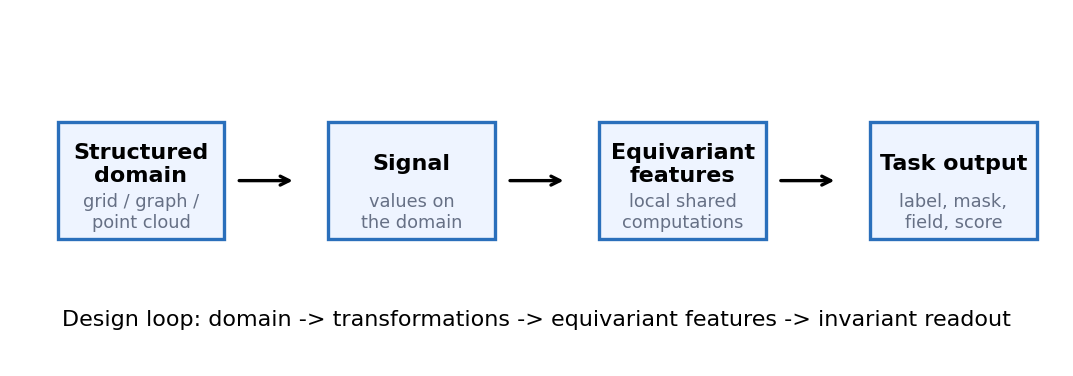

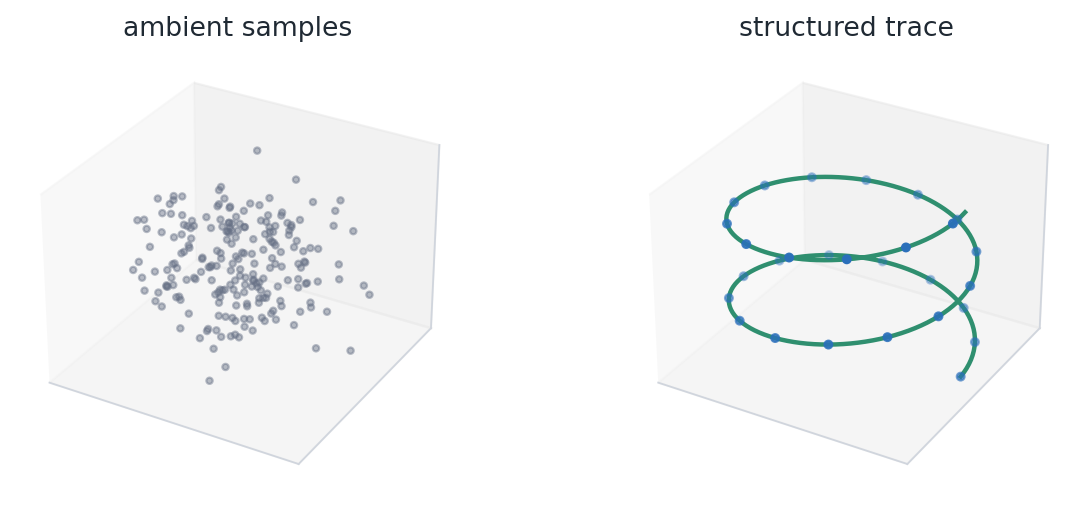

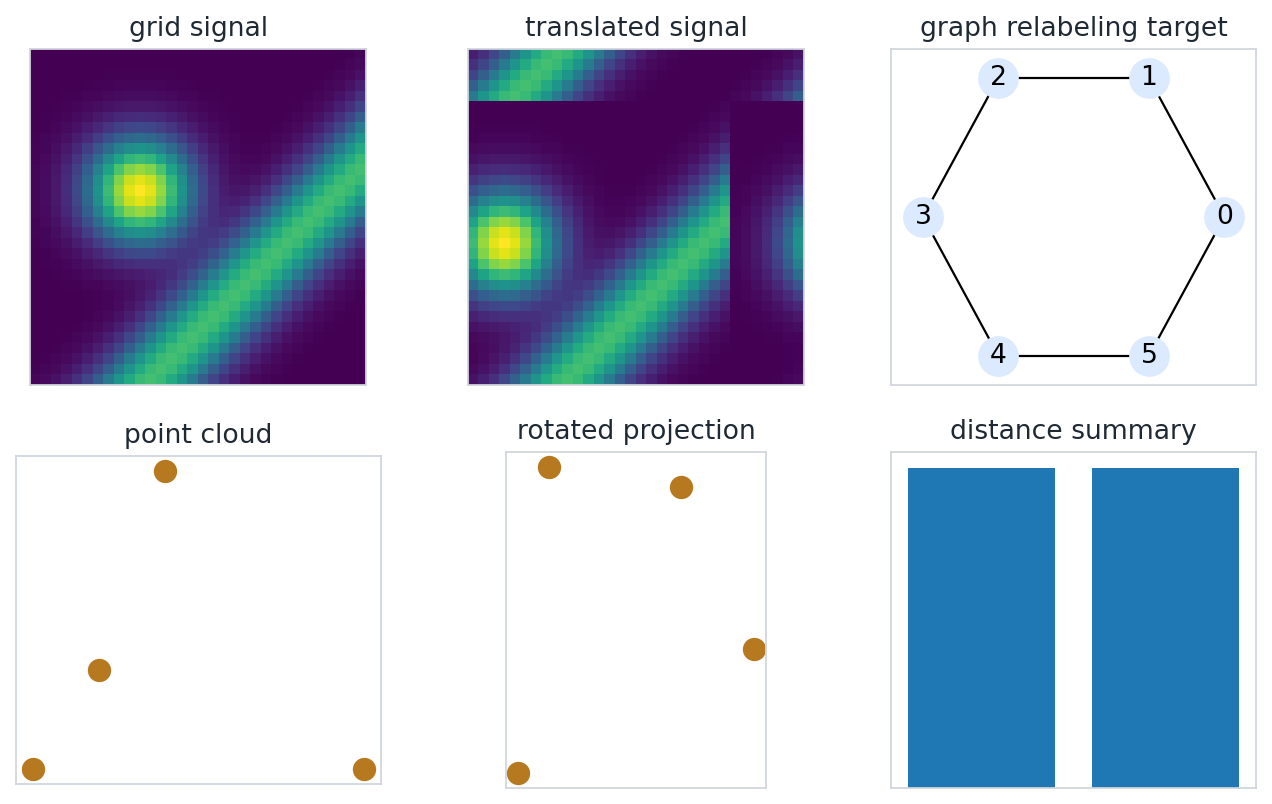

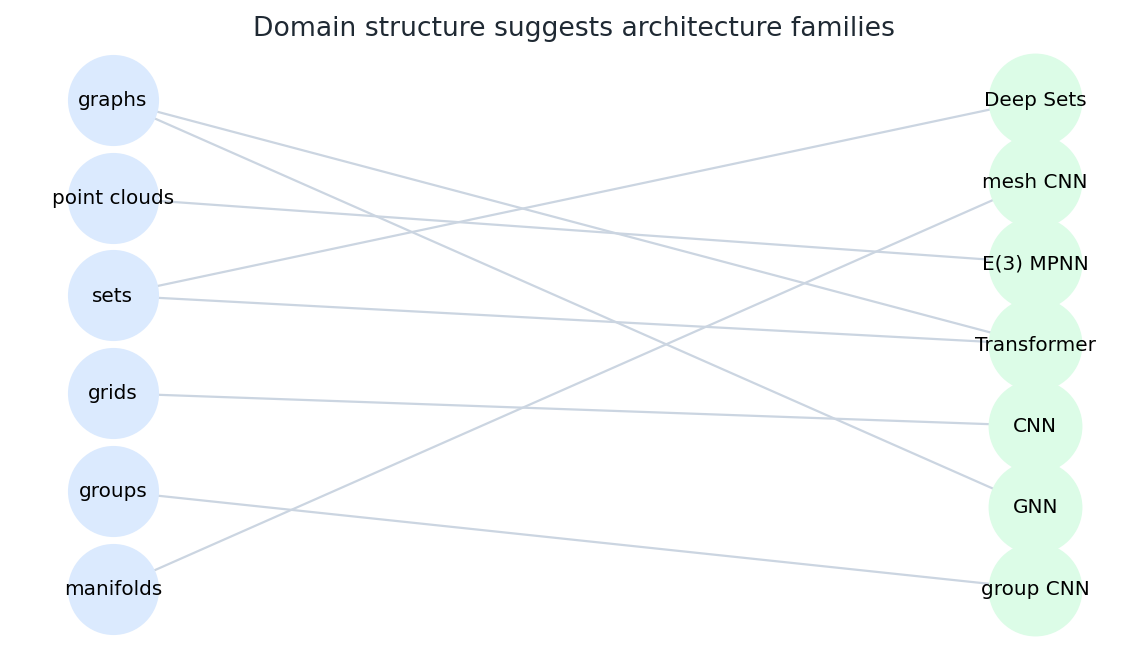

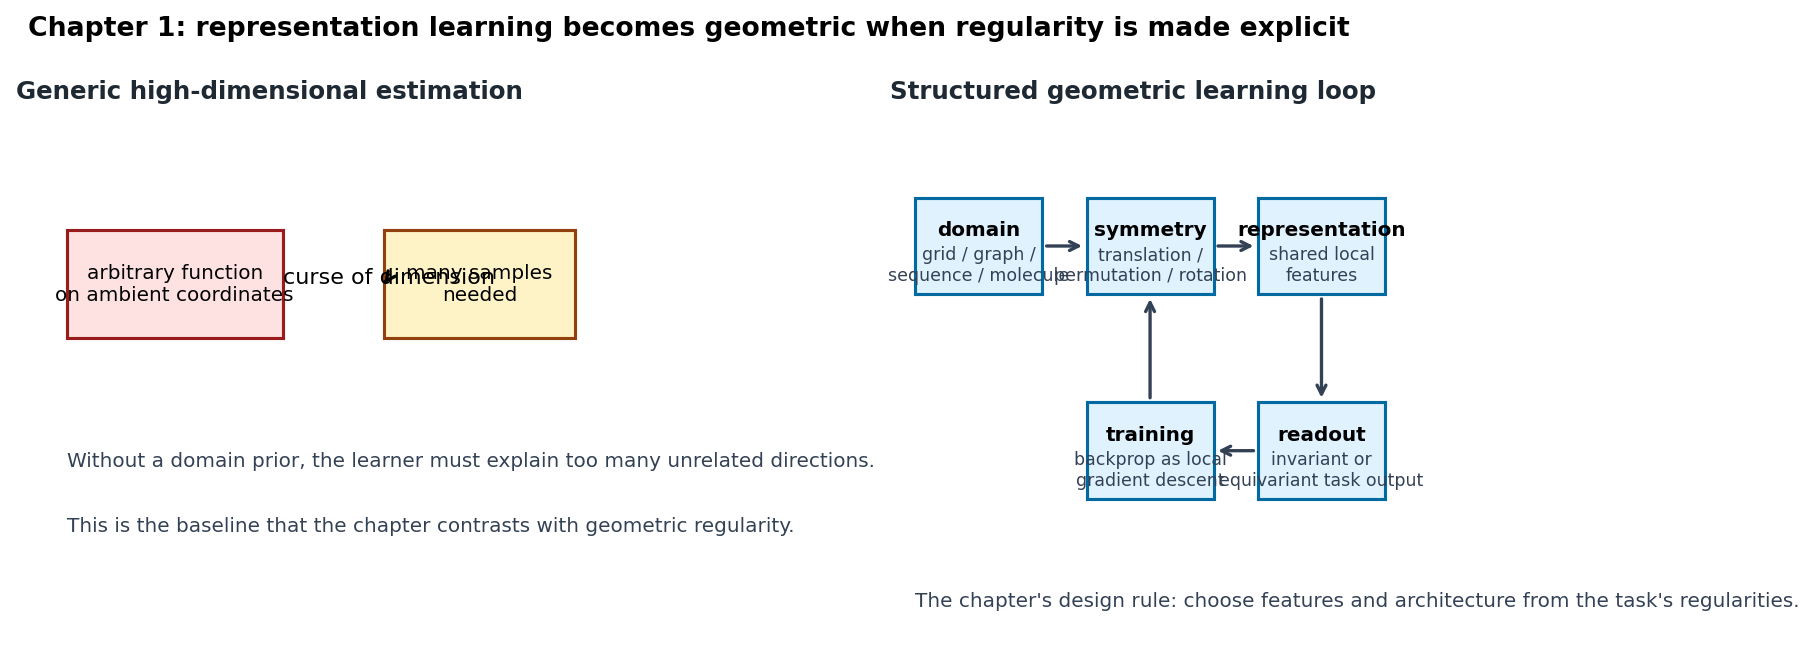

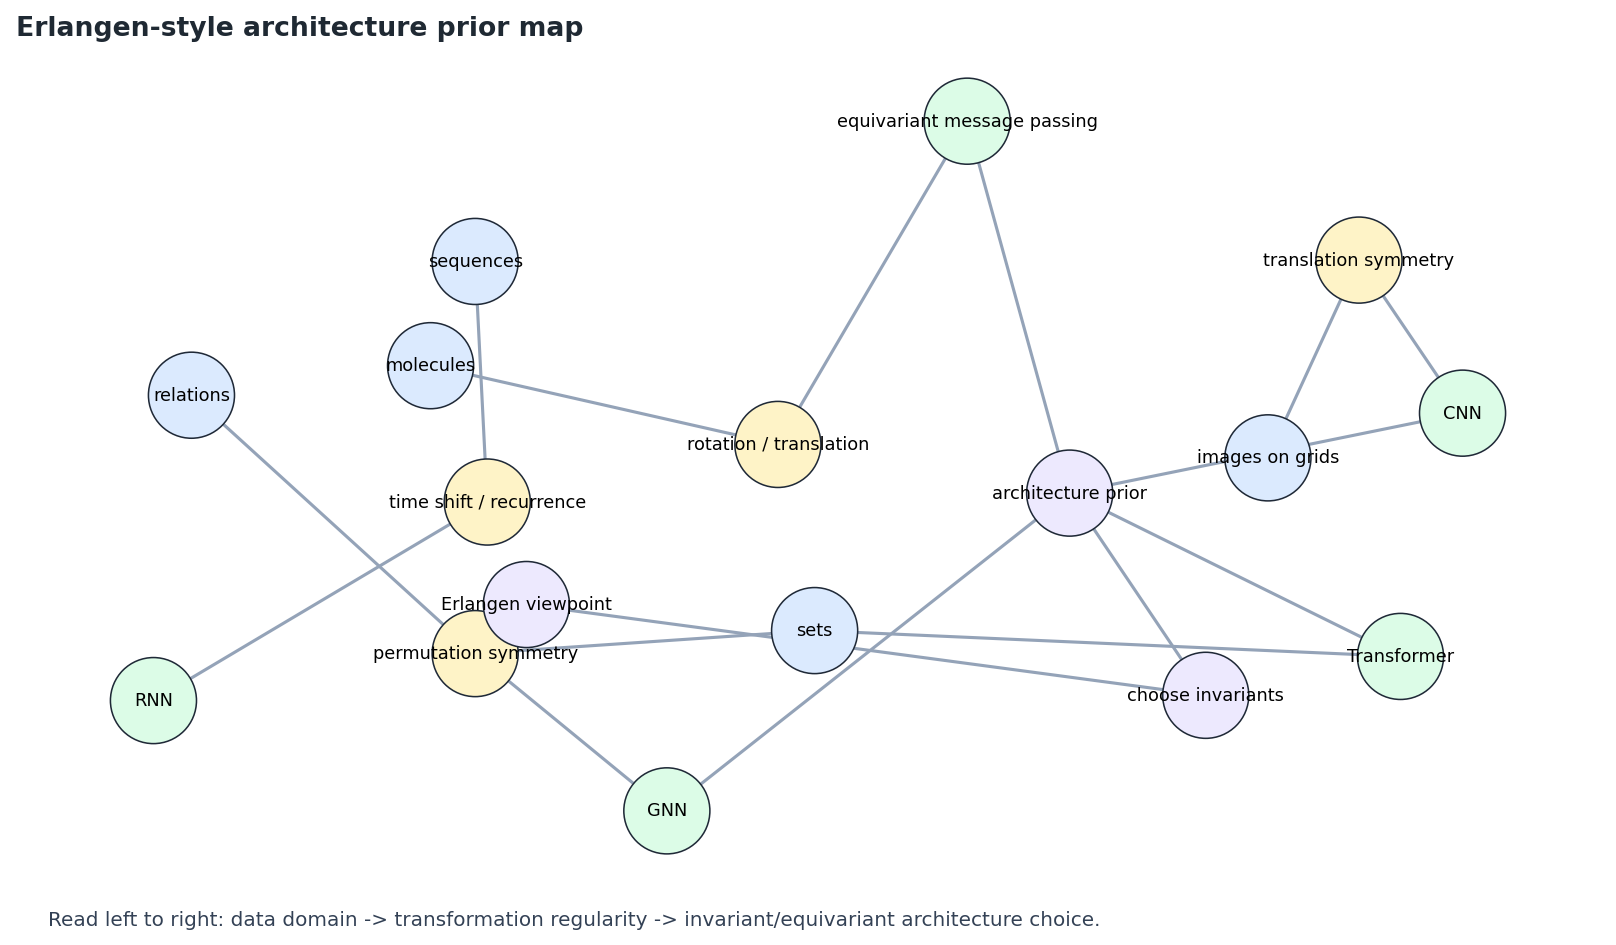

In [4]:

# Display the primary static visuals inline.
for path in ARTIFACTS:
    if path.suffix.lower() in {'.png', '.jpg', '.jpeg', '.gif', '.webp', '.svg'}:
        display_artifact(path, width=760)


In [5]:

# Display interactive HTML artifacts and link structured outputs.
for path in ARTIFACTS:
    if path.suffix.lower() in {'.html', '.htm'}:
        display_artifact(path, height=580)
    elif path.suffix.lower() in {'.json', '.csv'}:
        display_artifact(path)


In [6]:

summary = assert_artifacts(ARTIFACTS)
for path in ARTIFACTS:
    if path.suffix.lower() == '.png':
        image_nonblank(path)
    else:
        file_size(path)

if CHAPTER == 1:
    assert CHECKS['grid_convolution_equivariance_error'] < 1e-12
    assert CHECKS['distance_invariance_error'] < 1e-12
    assert CHECKS['taxonomy_orphan_nodes'] == 0
    assert CHECKS['architecture_prior_nodes_checked'] == 5
    assert CHECKS['source_claim_bucket_count'] >= 5
elif CHAPTER == 2:
    assert max(CHECKS['interpolant_train_errors'].values()) < 1e-8
    assert CHECKS['minimum_norm_error'] < 1e-3
elif CHAPTER == 3:
    assert CHECKS['d3_noncommutative'] and CHECKS['d3_closed']
    assert CHECKS['conv_equivariance_error'] < 1e-12
    assert CHECKS['pooling_invariance_error'] < 1e-12
elif CHAPTER == 4:
    assert CHECKS['graph_equivariance_error'] < 1e-12
    assert CHECKS['dft_offdiag_residual'] < 1e-10
    assert CHECKS['sphere_target_norm_error'] < 1e-12
elif CHAPTER == 5:
    assert CHECKS['cnn_translation_equivariance_error'] < 1e-12
    assert CHECKS['gnn_permutation_equivariance_error'] < 1e-12
    assert CHECKS['e3_distance_preservation_error'] < 1e-12
elif CHAPTER == 6:
    assert CHECKS['molecule_distance_error'] < 1e-12
    assert CHECKS['sequence_attention_row_error'] < 1e-12
    assert CHECKS['particle_count'] == 80
elif CHAPTER == 7:
    assert CHECKS['timeline_event_count'] >= 8
    assert CHECKS['lineage_dag']
    assert CHECKS['wl_histograms_match']

ledger = {'chapter': CHAPTER, 'checks': CHECKS, 'artifact_sizes': summary}
ledger_path = save_json(ledger, CHAPTER, f'chapter-{CHAPTER:02d}-notebook-ledger.json')
display(pd.DataFrame([{'check': key, 'value': str(value)[:100]} for key, value in CHECKS.items()]))
print(f'Notebook ledger: {ledger_path.relative_to(BOOK_ROOT)}')


,check,value
0,distance_invariance_error,2.220446049250313e-16
1,grid_convolution_equivariance_error,0.0
2,taxonomy_orphan_nodes,0
3,architecture_prior_nodes_checked,5
4,source_claim_bucket_count,5


Notebook ledger: artifacts\chapter-01\checks\chapter-01-notebook-ledger.json


## Deeper Reading Notes

This chapter's theme is structured domains, symmetry actions, and the design loop. The notebook treats that theme as a sequence of design decisions rather than a list of facts. First decide what the mathematical object is: a set of samples, a graph of relations, a grid with ordered neighbors, a point cloud with distances, a surface with tangent frames, or a sequence with temporal order. Then decide which changes of representation are merely coordinate changes and which changes should alter the answer. This separation is the main source of clarity in geometric deep learning.

The visuals should be read as arguments. A matrix heatmap is not only a picture of numbers; it shows whether relabeling, shifting, or diagonalizing behaves as claimed. A graph drawing is not an appeal to intuition alone; it pairs with a residual that checks permutation behavior. A point cloud view is not a molecular simulation; it is a controlled example where rigid motion preserves distances. The artifact is therefore both a teaching object and a small unit test for the concept.

When moving from these toy examples to real research code, the same questions remain useful. What transformations are built in exactly? What transformations are only approximated by data augmentation or optimization? Which quantities are invariant readouts, and which are equivariant intermediate fields? Where does locality enter, and how does pooling or message passing enlarge the scale? Which coordinate choices are arbitrary, and where must the model transport features between frames? Answering these questions often exposes whether an architecture matches the data before any training curve is plotted.

The chapter also has limits. The notebooks do not claim that a small synthetic example proves a theorem about large neural networks. They demonstrate the mechanism that a theorem, architecture, or experiment would later formalize at scale. That is why the final checks are intentionally narrow: they verify the invariant being taught, not every possible property of the method. A reader can extend the lab by replacing the toy domain with a larger one while keeping the same residuals.

A final way to use the notebook is as a vocabulary bridge. If a paper says equivariant, look for the representation and the commuting diagram. If it says invariant, look for the group action and the readout. If it says stable, look for a deformation metric and a bound or empirical sweep. If it says geometric, ask which domain structure is actually being used. This discipline keeps the word geometry from becoming decorative.



## Applied Lab And Takeaways

The applied lab is to make a controlled change to the geometric assumption and watch the checks respond. Change a permutation, modify a graph edge, alter the padding convention, rotate a point cloud, or perturb a mesh. The purpose is not to make every model invariant to every transformation. The purpose is to know which transformations the task should respect and which transformations carry semantic information.

Takeaways:

- Geometric deep learning starts from domains and transformations before it starts from layer names.
- Invariance, equivariance, stability, and locality are executable claims in these notebooks.
- The same blueprint explains many architectures while preserving their differences.
- Artifacts are part of the learning product; the final JSON ledger turns visual claims into auditable checks.
